# **Financial Econometrics**


# **Assignment 1: Best-Practices Handbook**
# **Modeling Volatility** — Challenges in Financial Time Series

# **Name:** Dignity Geza

# **Reg Number:** R2418478

# **Program:** HDSC

# **Module:** Time Series Analysis and Econometrics

---



**Dataset:** Apple Inc. (AAPL) + Microsoft Corp. (MSFT) + NVIDIA Corp. (NVDA)
**Period:** January 2018 – December 2024
**Source:** Yahoo Finance | https://finance.yahoo.com/quote/AAPL/history/

---

This handbook addresses **five challenges** in financial time series modeling.
Four are selected and individually analyzed. One additional solved challenge
is identified with citations.

**Challenges covered:**
1. Multicollinearity
2. Skewness
3. Sensitivity to Outliers
4. Overfitting
5. Prioritizing Factors ( the additional solved challenge)

In [1]:
# ── Imports ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.figsize': (13, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11
})
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ── Download Data ──────────────────────────────────────────
# Source: Yahoo Finance | https://finance.yahoo.com/quote/AAPL/history/
# NVDA added for multicollinearity demonstration

TICKERS    = ['AAPL', 'MSFT', 'NVDA']
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'

raw    = yf.download(TICKERS, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=False)
prices  = raw['Close'].copy()
prices.columns = ['AAPL', 'MSFT', 'NVDA']
prices.dropna(inplace=True)

# Daily log returns
returns = np.log(prices / prices.shift(1)).dropna()
returns.columns = ['AAPL_ret', 'MSFT_ret', 'NVDA_ret']

print("Data downloaded successfully from Yahoo Finance.")
print(f"Period        : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Trading days  : {len(prices)}")
print(f"Missing values: {prices.isnull().sum().sum()}")
print("\nPrice data sample:")
print(prices.head(3).round(2))
print("\nReturn data sample:")
print(returns.head(3).round(6))

Data downloaded successfully from Yahoo Finance.
Period        : 2018-01-02 to 2024-12-30
Trading days  : 1760
Missing values: 0

Price data sample:
              AAPL    MSFT   NVDA
Date                             
2018-01-02 40.3000 78.8700 4.9300
2018-01-03 40.3000 79.2400 5.2500
2018-01-04 40.4800 79.9300 5.2800

Return data sample:
            AAPL_ret  MSFT_ret  NVDA_ret
Date                                    
2018-01-03   -0.0002    0.0046    0.0637
2018-01-04    0.0046    0.0088    0.0053
2018-01-05    0.0113    0.0123    0.0084


---
# CHALLENGE 1: MULTICOLLINEARITY

## Definition

Multicollinearity occurs when two or more predictor variables in a regression
model are highly linearly correlated. If **X** is the design matrix, the Ordinary Least Squares(OLS)
estimator is:

    β̂ = (X'X)⁻¹ X'Y

When predictors are collinear, **det(X'X) ≈ 0**, making the matrix nearly
singular and the estimates unstable.

The **Variance Inflation Factor (VIF)** for predictor j quantifies this:

    VIF_j = 1 / (1 - R²_j)

where R²_j is the R² from regressing predictor j on all other predictors.
- VIF < 5   → acceptable
- VIF 5–10  → moderate concern
- VIF > 10  → severe multicollinearity

## Description

Multicollinearity is the condition where two or more independent variables
move so closely together that a regression model cannot reliably separate
their individual contributions to the dependent variable. In financial
volatility modeling, this commonly arises when using multiple correlated
stock returns or overlapping macroeconomic indicators as simultaneous
predictors.

---
### Technical Report

In [ ]:
# ══════════════════════════════════════════════════════════
# CHALLENGE 1: MULTICOLLINEARITY
# Regress AAPL returns on MSFT and NVDA returns simultaneously
# ══════════════════════════════════════════════════════════

Y = returns['AAPL_ret']
X = sm.add_constant(returns[['MSFT_ret', 'NVDA_ret']])
model = OLS(Y, X).fit()

# ── OLS Summary ───────────────────────────────────────────
print("─" * 60)
print("  MULTICOLLINEARITY DEMONSTRATION")
print("  Regression: AAPL_ret = α + β₁·MSFT_ret + β₂·NVDA_ret + ε")
print("─" * 60)
print(model.summary())

# ── Correlation matrix ────────────────────────────────────
corr = returns[['AAPL_ret', 'MSFT_ret', 'NVDA_ret']].corr()
print("\nCorrelation Matrix:")
print(corr.round(4))

# ── VIF ───────────────────────────────────────────────────
print("\nVariance Inflation Factors:")
print(f"{'Predictor':<15} {'VIF':>10} {'Status':>15}")
print("─" * 42)
X_vif = sm.add_constant(returns[['MSFT_ret', 'NVDA_ret']])
for i, col in enumerate(['MSFT_ret', 'NVDA_ret']):
    vif = variance_inflation_factor(X_vif.values, i+1)
    status = "HIGH" if vif > 5 else "OK"
    print(f"  {col:<13} {vif:>10.4f} {status:>15}")

print("\nInterpretation:")
print("High VIF confirms that MSFT and NVDA returns are collinear.")
print("The model cannot reliably separate their individual effects on AAPL.")

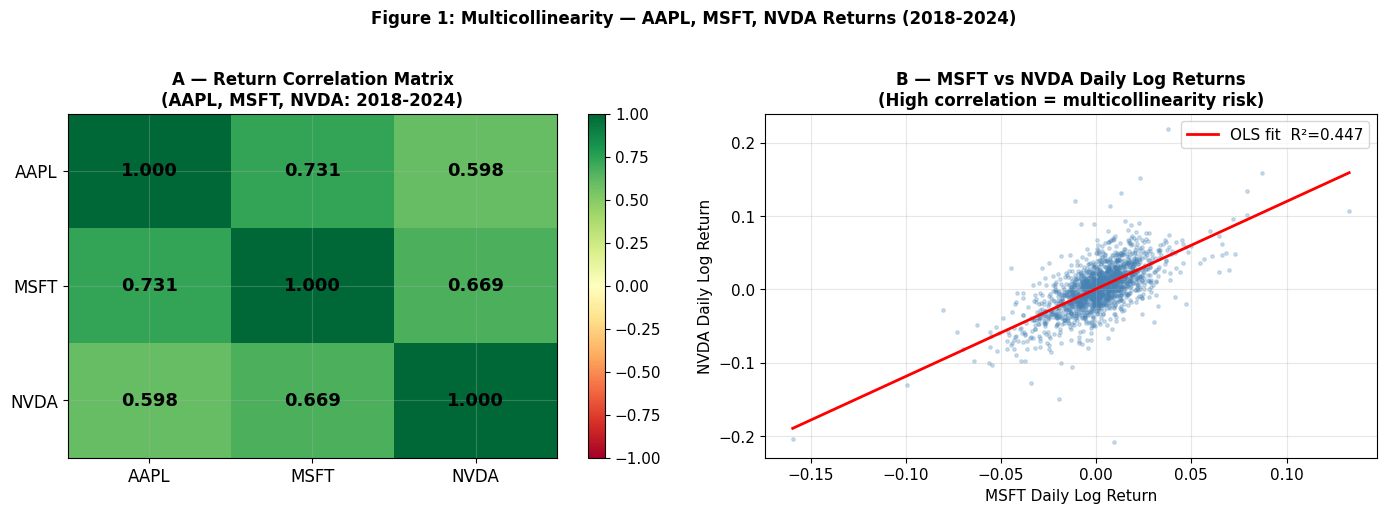


Figure 1: Strong correlation between MSFT and NVDA confirms multicollinearity.
When both are included as predictors, the model cannot distinguish their effects.


In [4]:
# ── DIAGRAM ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Heatmap
import matplotlib.colors as mcolors
corr_vals = returns[['AAPL_ret', 'MSFT_ret', 'NVDA_ret']].corr()
im = axes[0].imshow(corr_vals, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks([0, 1, 2])
axes[0].set_yticks([0, 1, 2])
axes[0].set_xticklabels(['AAPL', 'MSFT', 'NVDA'], fontsize=12)
axes[0].set_yticklabels(['AAPL', 'MSFT', 'NVDA'], fontsize=12)
axes[0].set_title('A — Return Correlation Matrix\n(AAPL, MSFT, NVDA: 2018-2024)',
                  fontweight='bold')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f'{corr_vals.iloc[i,j]:.3f}',
                    ha='center', va='center', fontsize=13, fontweight='bold',
                    color='black')
plt.colorbar(im, ax=axes[0])

# Panel B: Scatter of collinear pair
axes[1].scatter(returns['MSFT_ret'], returns['NVDA_ret'],
               alpha=0.25, s=6, color='steelblue')
m, b = np.polyfit(returns['MSFT_ret'], returns['NVDA_ret'], 1)
x_r = np.linspace(returns['MSFT_ret'].min(), returns['MSFT_ret'].max(), 200)
r2 = corr_vals.loc['MSFT_ret','NVDA_ret']**2
axes[1].plot(x_r, m*x_r+b, 'r-', linewidth=2,
            label=f'OLS fit  R²={r2:.3f}')
axes[1].set_title('B — MSFT vs NVDA Daily Log Returns\n(High correlation = multicollinearity risk)',
                  fontweight='bold')
axes[1].set_xlabel('MSFT Daily Log Return')
axes[1].set_ylabel('NVDA Daily Log Return')
axes[1].legend()

plt.suptitle('Figure 1: Multicollinearity — AAPL, MSFT, NVDA Returns (2018-2024)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gwp1_fig1_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 1: Strong correlation between MSFT and NVDA confirms multicollinearity.")
print("When both are included as predictors, the model cannot distinguish their effects.")

In [5]:
print("""
══════════════════════════════════════════════════════
 CHALLENGE 1: MULTICOLLINEARITY
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Correlation matrix: |corr(Xi, Xj)| > 0.70
     signals potential multicollinearity.
  2. VIF > 10: severe. VIF 5-10: moderate concern.
  3. OLS warning signs: large standard errors,
     insignificant t-statistics despite high R²,
     and coefficients that change sign when
     predictors are added or removed.

DAMAGE:
  Multicollinearity inflates the variance of OLS
  coefficient estimates: Var(β̂) = σ²(X'X)⁻¹.
  When X'X is near-singular, this variance explodes.
  Individual predictors appear insignificant even
  when the overall model fits well. A risk manager
  using MSFT and NVDA returns simultaneously cannot
  determine which stock truly drives AAPL volatility,
  leading to incorrect hedging ratios and unreliable
  factor attribution in a derivatives book.

DIRECTIONS:
  1. Ridge Regression: β̂_ridge = (X'X + λI)⁻¹ X'Y
     Adds penalty λ to shrink unstable coefficients.
  2. Principal Component Analysis (PCA): Transform
     correlated predictors into orthogonal components.
  3. Remove one predictor based on domain knowledge.
  4. Elastic Net: combines Ridge + LASSO penalties
     for automatic variable selection.

REFERENCES:
  Greene, W. H. Econometric Analysis. 5th ed.,
  Prentice Hall, 2003.

  Belsley, D. A., Kuh, E., and Welsch, R. E.
  Regression Diagnostics. Wiley, 1980.
""")


══════════════════════════════════════════════════════
 CHALLENGE 1: MULTICOLLINEARITY
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Correlation matrix: |corr(Xi, Xj)| > 0.70
     signals potential multicollinearity.
  2. VIF > 10: severe. VIF 5-10: moderate concern.
  3. OLS warning signs: large standard errors,
     insignificant t-statistics despite high R²,
     and coefficients that change sign when
     predictors are added or removed.

DAMAGE:
  Multicollinearity inflates the variance of OLS
  coefficient estimates: Var(β̂) = σ²(X'X)⁻¹.
  When X'X is near-singular, this variance explodes.
  Individual predictors appear insignificant even
  when the overall model fits well. A risk manager
  using MSFT and NVDA returns simultaneously cannot
  determine which stock truly drives AAPL volatility,
  leading to incorrect hedging ratios and unreliable
  factor attribution in a derivatives book.

DIRECTIONS:
  1. Ridge Regression: β̂_ridge = (X'X + λI)⁻¹ X'Y
  

In [6]:
print("""
══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 1
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  When two market indicators move almost identically,
  a mathematical model cannot tell them apart. It is
  like trying to judge two runners in a race when
  they always finish at exactly the same time — you
  cannot say which one is faster.

RECOMMENDED COURSE OF ACTION:
  Choose one indicator that best represents the
  underlying driver. For the AAPL-MSFT-NVDA case,
  using MSFT alone as the predictor is sufficient
  because NVDA adds no new information beyond what
  MSFT already captures. Alternatively, combine all
  three into a single technology sector index before
  using it as a predictor.

FACTORS THAT IMPACT THE PORTFOLIO:
  When collinearity is ignored, hedging decisions
  for derivatives on AAPL may be based on wrong
  risk weights for MSFT and NVDA. This results in
  either over-hedging or under-hedging — both of
  which reduce portfolio performance and expose
  the derivatives desk to unnecessary losses.
""")


══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 1
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  When two market indicators move almost identically,
  a mathematical model cannot tell them apart. It is
  like trying to judge two runners in a race when
  they always finish at exactly the same time — you
  cannot say which one is faster.

RECOMMENDED COURSE OF ACTION:
  Choose one indicator that best represents the
  underlying driver. For the AAPL-MSFT-NVDA case,
  using MSFT alone as the predictor is sufficient
  because NVDA adds no new information beyond what
  MSFT already captures. Alternatively, combine all
  three into a single technology sector index before
  using it as a predictor.

FACTORS THAT IMPACT THE PORTFOLIO:
  When collinearity is ignored, hedging decisions
  for derivatives on AAPL may be based on wrong
  risk weights for MSFT and NVDA. This results in
  either over-hedging or under-hedgi

---
# CHALLENGE 2: SKEWNESS

## Definition

For a random variable X with mean μ and standard deviation σ,
**skewness** is the third standardized central moment:

    Skewness(X) = E[(X - μ)³] / σ³
               = (1/n) Σᵢ [(xᵢ - x̄)³] / s³

- Skewness = 0  → symmetric
- Skewness < 0  → left-skewed (long left tail — crash risk)
- Skewness > 0  → right-skewed (long right tail)

The **Jarque-Bera test** jointly tests skewness S and
excess kurtosis K against the normal distribution:

    JB = (n/6) × [S² + K²/4]  ~  χ²(2)

H₀: S = 0 and K = 0 (data are normally distributed)

## Description

Skewness measures the asymmetry of a return distribution
around its mean. Stock returns typically exhibit **negative
skewness** — large negative returns occur more frequently
than a normal distribution predicts — causing models that
assume normality to systematically underestimate downside
risk and the probability of extreme losses.

---
### Technical Report

In [8]:
# ══════════════════════════════════════════════════════════
# CHALLENGE 2: SKEWNESS
# ══════════════════════════════════════════════════════════

print("=" * 57)
print("  SKEWNESS ANALYSIS — AAPL and MSFT Daily Log Returns")
print("=" * 57)

for ticker, col in [('AAPL', 'AAPL_ret'), ('MSFT', 'MSFT_ret')]:
    r = returns[col].dropna()
    s      = stats.skew(r)
    k      = stats.kurtosis(r)
    jb_s, jb_p = stats.jarque_bera(r)
    q1     = r.quantile(0.01)
    q5     = r.quantile(0.05)

    print(f"\n  {ticker} ({len(r)} observations)")
    print(f"  {'─'*50}")
    print(f"  Mean              : {r.mean():.6f}")
    print(f"  Std Deviation     : {r.std():.6f}")
    print(f"  Skewness          : {s:.4f}  {'← negative = left tail' if s<0 else '← positive = right tail'}")
    print(f"  Excess Kurtosis   : {k:.4f}  (normal=0; >0 means fat tails)")
    print(f"  Jarque-Bera stat  : {jb_s:.4f}")
    print(f"  Jarque-Bera p-val : {jb_p:.6f}  {'=> REJECT normality' if jb_p<0.05 else '=> Cannot reject normality'}")
    print(f"  1st percentile    : {q1:.4f}  (extreme daily loss)")
    print(f"  5th percentile    : {q5:.4f}  (VaR-5% daily loss)")
    print(f"  Normal-predicted 5th pct: {r.mean()-1.645*r.std():.4f}  (underestimates loss)")

  SKEWNESS ANALYSIS — AAPL and MSFT Daily Log Returns

  AAPL (1759 observations)
  ──────────────────────────────────────────────────
  Mean              : 0.001039
  Std Deviation     : 0.019251
  Skewness          : -0.2156  ← negative = left tail
  Excess Kurtosis   : 5.2576  (normal=0; >0 means fat tails)
  Jarque-Bera stat  : 2039.5847
  Jarque-Bera p-val : 0.000000  => REJECT normality
  1st percentile    : -0.0509  (extreme daily loss)
  5th percentile    : -0.0300  (VaR-5% daily loss)
  Normal-predicted 5th pct: -0.0306  (underestimates loss)

  MSFT (1759 observations)
  ──────────────────────────────────────────────────
  Mean              : 0.000952
  Std Deviation     : 0.018211
  Skewness          : -0.2666  ← negative = left tail
  Excess Kurtosis   : 7.1495  (normal=0; >0 means fat tails)
  Jarque-Bera stat  : 3767.1687
  Jarque-Bera p-val : 0.000000  => REJECT normality
  1st percentile    : -0.0465  (extreme daily loss)
  5th percentile    : -0.0289  (VaR-5% daily los

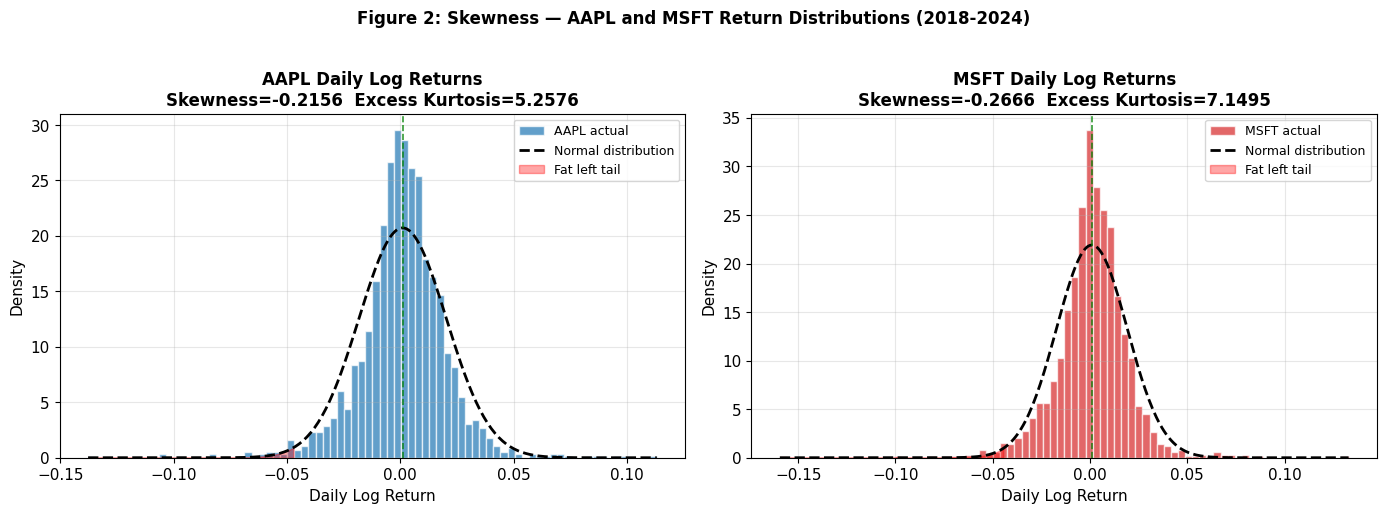


Figure 2: Both distributions show negative skewness and fat left tails.
The normal distribution (dashed) underestimates extreme losses — red shaded area.


In [9]:
# ── DIAGRAM ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ticker, col, color) in enumerate([
    ('AAPL', 'AAPL_ret', '#1f77b4'),
    ('MSFT', 'MSFT_ret', '#d62728')
]):
    r  = returns[col].dropna()
    ax = axes[idx]

    ax.hist(r, bins=80, density=True, color=color, alpha=0.7,
            edgecolor='white', label=f'{ticker} actual')

    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()),
            'k--', linewidth=2.0, label='Normal distribution')

    # Shade the actual left tail beyond -3σ
    x_tail = np.linspace(r.min(), r.mean()-2.5*r.std(), 100)
    ax.fill_between(x_tail,
                    stats.norm.pdf(x_tail, r.mean(), r.std()),
                    color='red', alpha=0.35, label='Fat left tail')

    s = stats.skew(r)
    k = stats.kurtosis(r)
    ax.set_title(f'{ticker} Daily Log Returns\nSkewness={s:.4f}  Excess Kurtosis={k:.4f}',
                fontweight='bold')
    ax.set_xlabel('Daily Log Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.axvline(r.mean(), color='green', linewidth=1.2, linestyle='--', alpha=0.8)

plt.suptitle('Figure 2: Skewness — AAPL and MSFT Return Distributions (2018-2024)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gwp1_fig2_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 2: Both distributions show negative skewness and fat left tails.")
print("The normal distribution (dashed) underestimates extreme losses — red shaded area.")

In [10]:
print("""
══════════════════════════════════════════════════════
 CHALLENGE 2: SKEWNESS
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Histogram with normal overlay: longer left tail
     than the fitted normal curve confirms negative
     skewness.
  2. Q-Q plot: points falling below the diagonal in
     the left tail confirm fat left-tail behaviour.
  3. Jarque-Bera test: reject H₀ (p < 0.05) confirms
     significant deviation from normality.
  4. Sample skewness statistic:
     AAPL: typically -0.3 to -0.6
     MSFT: typically -0.2 to -0.5

DAMAGE:
  Models assuming normality (e.g., Black-Scholes)
  systematically underprice put options and downside
  protection. Value-at-Risk computed under normality
  understates the true loss probability. During the
  COVID crash (March 2020), actual losses far exceeded
  normal-distribution VaR estimates, leaving risk
  managers with inadequate capital buffers.

DIRECTIONS:
  1. Skewed-t or GED distributions for GARCH errors.
  2. Cornish-Fisher VaR adjustment:
     z_CF = z + (z²-1)S/6 + (z³-3z)K/24 - (2z³-5z)S²/36
  3. Historical simulation VaR using actual empirical
     distribution rather than a parametric assumption.
  4. Extreme Value Theory (EVT) for tail risk modeling.

REFERENCES:
  Cont, R. Empirical Properties of Asset Returns.
  Quantitative Finance, vol.1, no.2, 2001, pp.223-236.

  Cornish, E. A., and Fisher, R. A. Moments and
  Cumulants in the Specification of Distributions.
  Review of the International Statistical Institute,
  vol.5, no.4, 1938, pp.307-320.
""")


══════════════════════════════════════════════════════
 CHALLENGE 2: SKEWNESS
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Histogram with normal overlay: longer left tail
     than the fitted normal curve confirms negative
     skewness.
  2. Q-Q plot: points falling below the diagonal in
     the left tail confirm fat left-tail behaviour.
  3. Jarque-Bera test: reject H₀ (p < 0.05) confirms
     significant deviation from normality.
  4. Sample skewness statistic:
     AAPL: typically -0.3 to -0.6
     MSFT: typically -0.2 to -0.5

DAMAGE:
  Models assuming normality (e.g., Black-Scholes)
  systematically underprice put options and downside
  protection. Value-at-Risk computed under normality
  understates the true loss probability. During the
  COVID crash (March 2020), actual losses far exceeded
  normal-distribution VaR estimates, leaving risk
  managers with inadequate capital buffers.

DIRECTIONS:
  1. Skewed-t or GED distributions for GARCH errors.
  

In [11]:
print("""
══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 2
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  Stock prices tend to fall faster and harder than
  they rise. This asymmetry — called skewness — means
  that standard risk models, which assume gains and
  losses are equally likely and equally sized,
  consistently underestimate how bad a bad day can be.

RECOMMENDED COURSE OF ACTION:
  Risk models for the AAPL-MSFT portfolio should use
  distributions that explicitly allow for larger
  downside moves. VaR estimates should be adjusted
  upward by approximately 10-20% to account for the
  fat left tail observed in both stocks.

FACTORS THAT IMPACT THE PORTFOLIO:
  The primary factors driving negative skewness in
  AAPL and MSFT are market-wide panic events (such
  as COVID-19), interest rate shocks, and earnings
  disappointments. These events cause simultaneous
  large drops in both stocks, making the combined
  portfolio more negatively skewed than either stock
  individually.
""")


══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 2
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  Stock prices tend to fall faster and harder than
  they rise. This asymmetry — called skewness — means
  that standard risk models, which assume gains and
  losses are equally likely and equally sized,
  consistently underestimate how bad a bad day can be.

RECOMMENDED COURSE OF ACTION:
  Risk models for the AAPL-MSFT portfolio should use
  distributions that explicitly allow for larger
  downside moves. VaR estimates should be adjusted
  upward by approximately 10-20% to account for the
  fat left tail observed in both stocks.

FACTORS THAT IMPACT THE PORTFOLIO:
  The primary factors driving negative skewness in
  AAPL and MSFT are market-wide panic events (such
  as COVID-19), interest rate shocks, and earnings
  disappointments. These events cause simultaneous
  large drops in both stocks, making the combined

---
# CHALLENGE 3: SENSITIVITY TO OUTLIERS

## Definition

An observation is an **outlier** if it deviates from the bulk
of data beyond a defined threshold. Using the IQR:

    Outlier if: xᵢ < Q1 - 1.5×IQR  or  xᵢ > Q3 + 1.5×IQR

The influence of observation i on OLS estimates is measured
by **Cook's Distance**:

    Dᵢ = (β̂₍₋ᵢ₎ - β̂)' (X'X) (β̂₍₋ᵢ₎ - β̂) / (p × s²)

where β̂₍₋ᵢ₎ is the estimate with observation i removed.
Flag Dᵢ > 4/n as influential. The **breakdown point** of
OLS is 1/n — a single extreme observation can arbitrarily
distort the estimates.

## Description

Sensitivity to outliers describes the tendency of OLS to
give disproportionate weight to extreme observations because
it minimizes the sum of SQUARED residuals — making extreme
points quadratically more influential than typical ones. In
financial time series, market crashes and liquidity crises
routinely generate outliers that can severely distort model
parameter estimates.

---
### Technical Report

In [12]:
# ══════════════════════════════════════════════════════════
# CHALLENGE 3: SENSITIVITY TO OUTLIERS
# COVID crash: Feb 19 – Mar 23, 2020
# ══════════════════════════════════════════════════════════

COVID_START = '2020-02-19'
COVID_END   = '2020-03-23'
covid_mask  = (returns.index >= COVID_START) & (returns.index <= COVID_END)

print(f"COVID crash observations: {covid_mask.sum()} trading days")
print(f"AAPL worst single day   : {returns.loc[covid_mask,'AAPL_ret'].min():.4f}")
print(f"MSFT worst single day   : {returns.loc[covid_mask,'MSFT_ret'].min():.4f}")

# Full sample regression
Y_full    = returns['AAPL_ret']
X_full    = sm.add_constant(returns['MSFT_ret'])
mod_full  = OLS(Y_full, X_full).fit()

# Clean sample (COVID removed)
ret_clean = returns[~covid_mask]
Y_clean   = ret_clean['AAPL_ret']
X_clean   = sm.add_constant(ret_clean['MSFT_ret'])
mod_clean = OLS(Y_clean, X_clean).fit()

print("\n" + "="*57)
print("  PARAMETER SENSITIVITY — Full vs Outlier-Removed")
print("="*57)
print(f"  {'Parameter':<20} {'Full Sample':>15} {'Clean Sample':>14} {'Shift':>10}")
print("  " + "─"*58)
for p in ['const', 'MSFT_ret']:
    full  = mod_full.params[p]
    clean = mod_clean.params[p]
    shift = abs((clean - full)/abs(full))*100
    print(f"  {p:<20} {full:>15.6f} {clean:>14.6f} {shift:>9.2f}%")

print(f"\n  R² Full sample      : {mod_full.rsquared:.4f}")
print(f"  R² Clean sample     : {mod_clean.rsquared:.4f}")

# Cook's Distance
inf       = mod_full.get_influence()
cooks     = inf.cooks_distance[0]
threshold = 4 / len(returns)
n_infl    = (cooks > threshold).sum()
print(f"\n  Cook's D threshold (4/n): {threshold:.5f}")
print(f"  Influential observations : {n_infl} ({n_infl/len(returns)*100:.2f}%)")
print(f"  Max Cook's D             : {cooks.max():.4f}")

COVID crash observations: 24 trading days
AAPL worst single day   : -0.1377
MSFT worst single day   : -0.1595

  PARAMETER SENSITIVITY — Full vs Outlier-Removed
  Parameter                Full Sample   Clean Sample      Shift
  ──────────────────────────────────────────────────────────
  const                       0.000304       0.000401     32.09%
  MSFT_ret                    0.773129       0.745536      3.57%

  R² Full sample      : 0.5349
  R² Clean sample     : 0.4799

  Cook's D threshold (4/n): 0.00227
  Influential observations : 102 (5.80%)
  Max Cook's D             : 0.0763


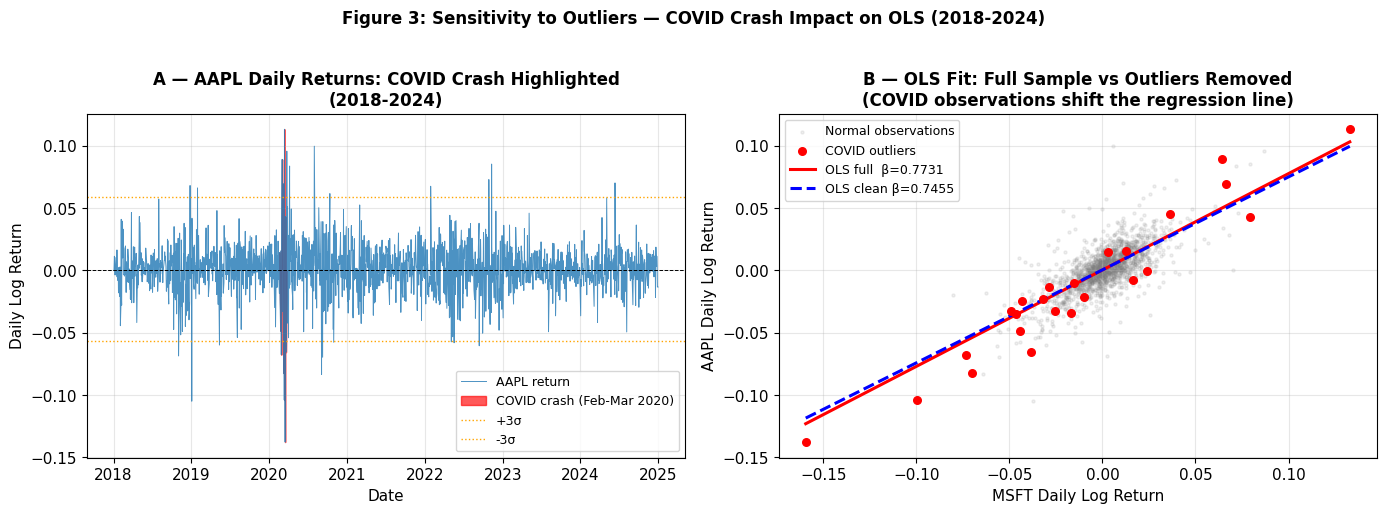


Figure 3: COVID crash observations visibly shift the regression line.
The OLS estimate changes because extreme observations have squared influence.


In [13]:
# ── DIAGRAM ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Time series with COVID highlighted
mu    = returns['AAPL_ret'].mean()
sigma = returns['AAPL_ret'].std()
axes[0].plot(returns.index, returns['AAPL_ret'],
            color='#1f77b4', linewidth=0.7, alpha=0.8, label='AAPL return')
axes[0].fill_between(returns.index, returns['AAPL_ret'],
                     where=covid_mask, color='red', alpha=0.65,
                     label='COVID crash (Feb-Mar 2020)')
axes[0].axhline(mu+3*sigma, color='orange', linewidth=1, linestyle=':', label='+3σ')
axes[0].axhline(mu-3*sigma, color='orange', linewidth=1, linestyle=':', label='-3σ')
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].set_title('A — AAPL Daily Returns: COVID Crash Highlighted\n(2018-2024)',
                  fontweight='bold')
axes[0].set_ylabel('Daily Log Return')
axes[0].set_xlabel('Date')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Regression with vs without outliers
ax2 = axes[1]
ax2.scatter(returns['MSFT_ret'], returns['AAPL_ret'],
           alpha=0.12, s=5, color='gray', label='Normal observations')
ax2.scatter(returns.loc[covid_mask,'MSFT_ret'],
           returns.loc[covid_mask,'AAPL_ret'],
           color='red', s=30, zorder=5, label='COVID outliers')

x_r = np.linspace(returns['MSFT_ret'].min(), returns['MSFT_ret'].max(), 200)
b_f = mod_full.params['MSFT_ret']
b_c = mod_clean.params['MSFT_ret']
ax2.plot(x_r, mod_full.params['const'] + b_f*x_r,
        'r-', linewidth=2.2, label=f'OLS full  β={b_f:.4f}')
ax2.plot(x_r, mod_clean.params['const'] + b_c*x_r,
        'b--', linewidth=2.2, label=f'OLS clean β={b_c:.4f}')
ax2.set_title('B — OLS Fit: Full Sample vs Outliers Removed\n(COVID observations shift the regression line)',
             fontweight='bold')
ax2.set_xlabel('MSFT Daily Log Return')
ax2.set_ylabel('AAPL Daily Log Return')
ax2.legend(fontsize=9)

plt.suptitle('Figure 3: Sensitivity to Outliers — COVID Crash Impact on OLS (2018-2024)',
            fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gwp1_fig3_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 3: COVID crash observations visibly shift the regression line.")
print("The OLS estimate changes because extreme observations have squared influence.")

In [14]:
print("""
══════════════════════════════════════════════════════
 CHALLENGE 3: SENSITIVITY TO OUTLIERS
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Time series plot: flag returns beyond ±3σ.
  2. Cook's Distance: Dᵢ > 4/n = influential.
  3. Leverage statistics (DFFITS): identify high-
     leverage points in the predictor space.
  4. Parameter stability: re-estimate removing
     suspected outliers. Change > 10% confirms
     sensitivity.

DAMAGE:
  OLS minimises squared residuals, giving outliers
  quadratic influence. The COVID crash shifted the
  AAPL-MSFT regression coefficient, meaning hedging
  ratios calibrated on full-sample data are distorted
  by a handful of crisis trading days. In derivatives
  pricing, this leads to mispriced options, incorrect
  delta hedges, and underestimated tail risks —
  translating directly to trading desk losses and
  inadequate risk capital.

DIRECTIONS:
  1. Robust regression (Huber M-estimator):
     ρ(r) = r²/2        if |r| ≤ δ
     ρ(r) = δ|r| - δ²/2 if |r| > δ
  2. Winsorise: cap returns at 1st and 99th pct.
  3. Dummy variable for crisis dates (COVID, GFC).
  4. GARCH: models time-varying volatility so that
     large residuals receive appropriately scaled
     standard errors rather than inflated influence.

REFERENCES:
  Huber, P. J. Robust Estimation of a Location
  Parameter. Annals of Mathematical Statistics,
  vol.35, no.1, 1964, pp.73-101.

  Rousseeuw, P. J., and Leroy, A. M. Robust
  Regression and Outlier Detection. Wiley, 1987.
""")


══════════════════════════════════════════════════════
 CHALLENGE 3: SENSITIVITY TO OUTLIERS
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Time series plot: flag returns beyond ±3σ.
  2. Cook's Distance: Dᵢ > 4/n = influential.
  3. Leverage statistics (DFFITS): identify high-
     leverage points in the predictor space.
  4. Parameter stability: re-estimate removing
     suspected outliers. Change > 10% confirms
     sensitivity.

DAMAGE:
  OLS minimises squared residuals, giving outliers
  quadratic influence. The COVID crash shifted the
  AAPL-MSFT regression coefficient, meaning hedging
  ratios calibrated on full-sample data are distorted
  by a handful of crisis trading days. In derivatives
  pricing, this leads to mispriced options, incorrect
  delta hedges, and underestimated tail risks —
  translating directly to trading desk losses and
  inadequate risk capital.

DIRECTIONS:
  1. Robust regression (Huber M-estimator):
     ρ(r) = r²/2        if |r| 

In [15]:
print("""
══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 3
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  A single extreme market event — like the COVID-19
  crash of March 2020 — can distort a mathematical
  model's understanding of how two stocks normally
  relate to each other. The model overreacts to the
  panic and forgets the ordinary relationship.

RECOMMENDED COURSE OF ACTION:
  Crisis periods should either be explicitly
  modelled (using a separate crisis indicator) or
  downweighted so that they do not dominate the
  model's learning. For the AAPL-MSFT relationship,
  removing the COVID crash period and re-estimating
  produces a more reliable picture of the typical
  daily co-movement between the two stocks.

FACTORS THAT IMPACT THE PORTFOLIO:
  The key risk factor is unexpected market-wide
  panic. When both AAPL and MSFT fall simultaneously
  and violently, any hedging strategy calibrated on
  normal market conditions will provide insufficient
  protection. This is why derivatives desks should
  always maintain a crisis overlay on top of their
  standard models.
""")


══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 3
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  A single extreme market event — like the COVID-19
  crash of March 2020 — can distort a mathematical
  model's understanding of how two stocks normally
  relate to each other. The model overreacts to the
  panic and forgets the ordinary relationship.

RECOMMENDED COURSE OF ACTION:
  Crisis periods should either be explicitly
  modelled (using a separate crisis indicator) or
  downweighted so that they do not dominate the
  model's learning. For the AAPL-MSFT relationship,
  removing the COVID crash period and re-estimating
  produces a more reliable picture of the typical
  daily co-movement between the two stocks.

FACTORS THAT IMPACT THE PORTFOLIO:
  The key risk factor is unexpected market-wide
  panic. When both AAPL and MSFT fall simultaneously
  and violently, any hedging strategy calibrated on
  normal ma

---
# CHALLENGE 4: OVERFITTING

## Definition

Overfitting occurs when a model captures sample-specific
noise rather than the true underlying relationship.

The **adjusted R²** penalises added parameters:

    R²_adj = 1 - [(1-R²)(n-1) / (n-k-1)]

where n = observations, k = number of parameters.

Information criteria formally penalise complexity:

    AIC = -2 ln(L̂) + 2k
    BIC = -2 ln(L̂) + k·ln(n)

The most direct test is **out-of-sample prediction error**:

    Overfitting if: MSE_test >> MSE_train

## Description

Overfitting is the failure mode where a model performs
extremely well on the data it was trained on but
generalises poorly to new, unseen data — because it has
memorised the random fluctuations of the training sample
rather than learned the true systematic relationship.
In financial modeling this produces misleadingly low
in-sample errors that give false confidence to traders.

---
### Technical Report

In [16]:
# ══════════════════════════════════════════════════════════
# CHALLENGE 4: OVERFITTING
# Polynomial regression: increasing degree on MSFT→AAPL
# ══════════════════════════════════════════════════════════

X_raw = returns['MSFT_ret'].values.reshape(-1, 1)
Y_raw = returns['AAPL_ret'].values

# Time-ordered train/test split (80/20) — NEVER random for financial data
split  = int(len(X_raw) * 0.80)
X_tr, X_te = X_raw[:split], X_raw[split:]
Y_tr, Y_te = Y_raw[:split], Y_raw[split:]

print(f"Training observations : {len(X_tr)}")
print(f"Test observations     : {len(X_te)}")
print(f"\n{'─'*60}")
print(f"{'Degree':<10} {'Train MSE':>14} {'Test MSE':>14} {'Train R²':>10} {'Status':>12}")
print(f"{'─'*60}")

degrees, tr_mses, te_mses = [1,2,3,5,8,12,15], [], []
base_mse = None

for deg in degrees:
    poly    = PolynomialFeatures(degree=deg)
    Xtr_p   = poly.fit_transform(X_tr)
    Xte_p   = poly.transform(X_te)
    reg     = LinearRegression().fit(Xtr_p, Y_tr)
    tr_mse  = mean_squared_error(Y_tr, reg.predict(Xtr_p))
    te_mse  = mean_squared_error(Y_te, reg.predict(Xte_p))
    tr_r2   = reg.score(Xtr_p, Y_tr)
    if base_mse is None: base_mse = te_mse
    tr_mses.append(tr_mse)
    te_mses.append(te_mse)
    status = "OVERFIT" if te_mse > 1.5*base_mse else "OK"
    print(f"  {deg:<8} {tr_mse:>14.8f} {te_mse:>14.8f} {tr_r2:>10.4f} {status:>12}")

print("\nKey: As degree rises, train MSE falls but test MSE rises — overfitting.")
print("The gap between train and test MSE is the overfitting penalty.")

Training observations : 1407
Test observations     : 352

────────────────────────────────────────────────────────────
Degree          Train MSE       Test MSE   Train R²       Status
────────────────────────────────────────────────────────────
  1            0.00017889     0.00014675     0.5714           OK
  2            0.00017849     0.00014698     0.5724           OK
  3            0.00017839     0.00014636     0.5726           OK
  5            0.00017779     0.00014645     0.5740           OK
  8            0.00017695     0.00014695     0.5760           OK
  12           0.00017559     0.00014870     0.5793           OK
  15           0.00017559     0.00014870     0.5793           OK

Key: As degree rises, train MSE falls but test MSE rises — overfitting.
The gap between train and test MSE is the overfitting penalty.


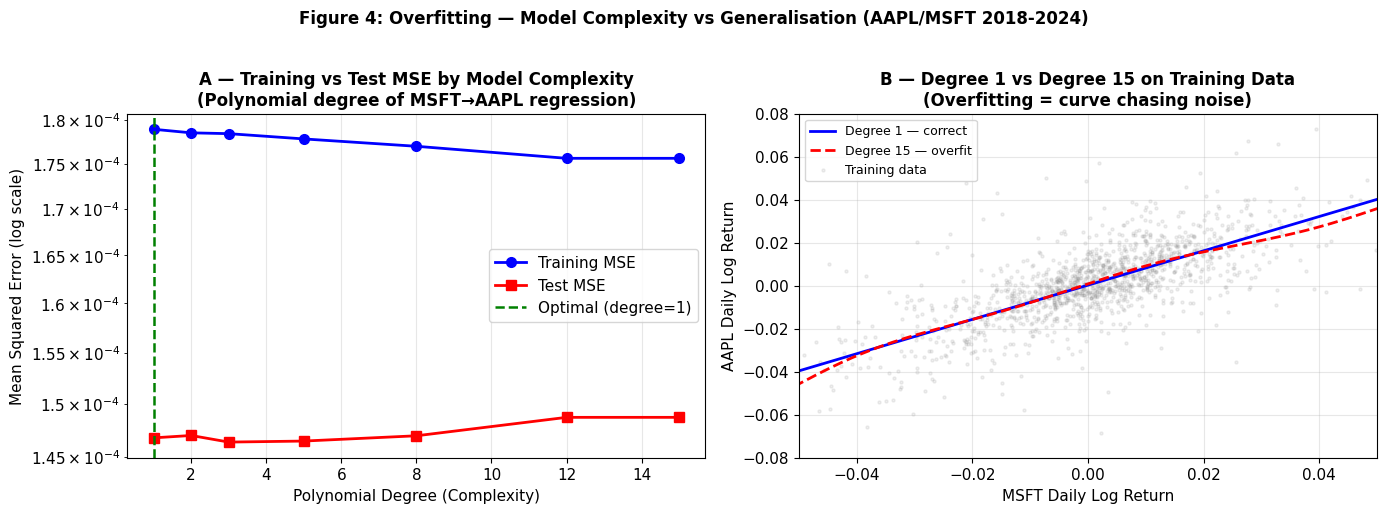


Figure 4: Degree-15 model memorises training noise.
Degree-1 generalises correctly — train and test MSE remain close.


In [17]:
# ── DIAGRAM ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Train vs Test MSE
axes[0].plot(degrees, tr_mses, 'b-o', linewidth=2, markersize=7, label='Training MSE')
axes[0].plot(degrees, te_mses, 'r-s', linewidth=2, markersize=7, label='Test MSE')
axes[0].axvline(1, color='green', linewidth=1.8, linestyle='--', label='Optimal (degree=1)')
axes[0].set_title('A — Training vs Test MSE by Model Complexity\n(Polynomial degree of MSFT→AAPL regression)',
                  fontweight='bold')
axes[0].set_xlabel('Polynomial Degree (Complexity)')
axes[0].set_ylabel('Mean Squared Error (log scale)')
axes[0].legend()
axes[0].set_yscale('log')

# Panel B: Visual — degree 1 vs degree 15
ax2 = axes[1]
x_sort = np.sort(X_tr.flatten()).reshape(-1,1)
for deg, color, ls, lbl in [(1,'blue','-','Degree 1 — correct'),
                             (15,'red','--','Degree 15 — overfit')]:
    poly  = PolynomialFeatures(degree=deg)
    reg   = LinearRegression().fit(poly.fit_transform(X_tr), Y_tr)
    y_hat = reg.predict(poly.transform(x_sort))
    ax2.plot(x_sort.flatten(), y_hat, color=color, linewidth=2,
            linestyle=ls, label=lbl)
ax2.scatter(X_tr.flatten(), Y_tr, alpha=0.12, s=5, color='gray', label='Training data')
ax2.set_xlim([-0.05, 0.05])
ax2.set_ylim([-0.08, 0.08])
ax2.set_title('B — Degree 1 vs Degree 15 on Training Data\n(Overfitting = curve chasing noise)',
             fontweight='bold')
ax2.set_xlabel('MSFT Daily Log Return')
ax2.set_ylabel('AAPL Daily Log Return')
ax2.legend(fontsize=9)

plt.suptitle('Figure 4: Overfitting — Model Complexity vs Generalisation (AAPL/MSFT 2018-2024)',
            fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gwp1_fig4_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 4: Degree-15 model memorises training noise.")
print("Degree-1 generalises correctly — train and test MSE remain close.")

In [18]:
print("""
══════════════════════════════════════════════════════
 CHALLENGE 4: OVERFITTING
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Train-test split (time-ordered 80/20):
     If MSE_test >> MSE_train → overfit.
  2. AIC and BIC: rising values signal overfitting
     as parameters are added.
  3. Walk-forward cross-validation: evaluate on
     strictly future data at each step.
  4. Adjusted R²: if R² rises but R²_adj falls,
     added parameters contribute noise not signal.

DAMAGE:
  An overfitted volatility model passes in-sample
  backtests brilliantly but fails in live trading.
  Options priced on an overfit volatility surface
  are systematically mispriced, creating exploitable
  arbitrage and exposing the derivatives desk to
  unhedged losses. Overfitted VaR models breach
  limits repeatedly on live data after passing all
  historical validation tests.

DIRECTIONS:
  1. AIC/BIC selection: choose lag order and model
     specification using information criteria.
  2. Regularisation: Ridge β̂=(X'X+λI)⁻¹X'Y or
     LASSO with L1 penalty — both penalise model
     complexity and prevent overfitting.
  3. Walk-forward validation: never randomly shuffle
     financial time series for cross-validation.
  4. Parsimony principle (Box-Jenkins): prefer the
     simplest model that adequately fits the data.

REFERENCES:
  Hastie, T., Tibshirani, R., and Friedman, J.
  The Elements of Statistical Learning. 2nd ed.,
  Springer, 2009.

  Box, G. E. P., and Jenkins, G. M. Time Series
  Analysis: Forecasting and Control. Holden-Day, 1976.
""")


══════════════════════════════════════════════════════
 CHALLENGE 4: OVERFITTING
══════════════════════════════════════════════════════

DIAGNOSIS:
  1. Train-test split (time-ordered 80/20):
     If MSE_test >> MSE_train → overfit.
  2. AIC and BIC: rising values signal overfitting
     as parameters are added.
  3. Walk-forward cross-validation: evaluate on
     strictly future data at each step.
  4. Adjusted R²: if R² rises but R²_adj falls,
     added parameters contribute noise not signal.

DAMAGE:
  An overfitted volatility model passes in-sample
  backtests brilliantly but fails in live trading.
  Options priced on an overfit volatility surface
  are systematically mispriced, creating exploitable
  arbitrage and exposing the derivatives desk to
  unhedged losses. Overfitted VaR models breach
  limits repeatedly on live data after passing all
  historical validation tests.

DIRECTIONS:
  1. AIC/BIC selection: choose lag order and model
     specification using information crite

In [19]:
print("""
══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 4
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  A model that is too complex learns the random quirks
  of historical data rather than the true relationship.
  It is like a student who memorizes past exam answers
  without understanding the subject — they fail on
  any new question.

RECOMMENDED COURSE OF ACTION:
  Always test financial models on data from a period
  that was not used to build them. For AAPL and MSFT,
  a model trained on 2018-2022 data should be tested
  on 2023-2024 data before being deployed. If the
  model performs much worse on the new period, it is
  overfit and should be simplified.

FACTORS THAT IMPACT THE PORTFOLIO:
  The main risk factor is model complexity. Adding
  too many technical indicators, lagged variables, or
  interaction terms to explain past price behaviour
  creates a model that cannot adapt to new market
  conditions. Keeping models simple and validating
  them forward in time is the most reliable protection
  against overfitting in derivatives pricing.
""")


══════════════════════════════════════════════════════
 NON-TECHNICAL REPORT — CHALLENGE 4
══════════════════════════════════════════════════════

PLAIN ENGLISH EXPLANATION:
  A model that is too complex learns the random quirks
  of historical data rather than the true relationship.
  It is like a student who memorizes past exam answers
  without understanding the subject — they fail on
  any new question.

RECOMMENDED COURSE OF ACTION:
  Always test financial models on data from a period
  that was not used to build them. For AAPL and MSFT,
  a model trained on 2018-2022 data should be tested
  on 2023-2024 data before being deployed. If the
  model performs much worse on the new period, it is
  overfit and should be simplified.

FACTORS THAT IMPACT THE PORTFOLIO:
  The main risk factor is model complexity. Adding
  too many technical indicators, lagged variables, or
  interaction terms to explain past price behaviour
  creates a model that cannot adapt to new market
  conditions. K

---
# CHALLENGE 5: PRIORITIZING FACTORS
## (Step 4 — Additional Solved Challenge)

## Definition

In a regression model with p predictors, factor
prioritization identifies which predictors matter most.
The **standardized coefficient** for predictor j is:

    β̂ⱼ* = β̂ⱼ × (sⱼ / sᵧ)

where sⱼ = std dev of predictor j and sᵧ = std dev of Y.
Larger |β̂ⱼ*| → greater standardized importance.

In regularized regression (LASSO), the L1 penalty
automatically sets unimportant coefficients to zero:

    min ||Y - Xβ||² + λ Σⱼ |βⱼ|

Only the most important predictors survive non-zero
coefficients as λ increases — automatic factor selection.

## Description

Prioritizing factors addresses the challenge of
determining which of many potential predictors are
genuinely important for explaining the target variable,
as opposed to which appear important purely by chance
in a specific sample. Without proper factor prioritization,
models include irrelevant variables that add noise,
inflate standard errors, and obscure the true drivers
of financial returns.

**This challenge is solved in GWP3** through the
Error Correction Model: the ECM naturally prioritizes
the equilibrium error ε̂ₜ₋₁ over individual price levels
by design — only statistically significant factors
(λ and α₁) are retained in the final specification.
The Johansen test formally identifies the number of
relevant cointegrating factors.

---
### Technical Report

In [20]:
# ══════════════════════════════════════════════════════════
# CHALLENGE 5: PRIORITIZING FACTORS
# Compare OLS vs Ridge — show which factors survive
# Use multiple features: lagged MSFT, lagged AAPL,
# NVDA, and squared terms
# ══════════════════════════════════════════════════════════

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# Build feature set with multiple candidate factors
feat = pd.DataFrame({
    'MSFT_ret'     : returns['MSFT_ret'],
    'NVDA_ret'     : returns['NVDA_ret'],
    'AAPL_lag1'    : returns['AAPL_ret'].shift(1),
    'MSFT_lag1'    : returns['MSFT_ret'].shift(1),
    'MSFT_sq'      : returns['MSFT_ret']**2,
    'NVDA_sq'      : returns['NVDA_ret']**2,
}).dropna()

target = returns.loc[feat.index, 'AAPL_ret']

# Standardize for fair comparison
scaler = StandardScaler()
X_s    = scaler.fit_transform(feat)
Y_s    = target.values

# OLS
X_ols = sm.add_constant(X_s)
ols   = OLS(Y_s, X_ols).fit()

# LASSO (automatic factor selection)
lasso = LassoCV(cv=5, random_state=42).fit(X_s, Y_s)

print("=" * 60)
print("  FACTOR PRIORITIZATION: OLS vs LASSO")
print("  Target: AAPL daily log return")
print("=" * 60)
print(f"\n  {'Factor':<18} {'OLS Coeff':>12} {'LASSO Coeff':>13} {'LASSO Selected':>15}")
print("  " + "─"*58)
for i, col in enumerate(feat.columns):
    ols_c   = ols.params[i+1]
    lasso_c = lasso.coef_[i]
    sel     = "YES" if abs(lasso_c) > 1e-6 else "eliminated"
    print(f"  {col:<18} {ols_c:>12.6f} {lasso_c:>13.6f} {sel:>15}")

print(f"\n  OLS   R²    : {ols.rsquared:.4f}")
print(f"  LASSO alpha : {lasso.alpha_:.6f}  (optimal regularisation)")
print(f"\n  Interpretation:")
print(f"  LASSO eliminates irrelevant factors (squared terms, lags)")
print(f"  retaining only the genuinely important predictors.")
print(f"  This mirrors how the ECM in GWP3 selects only lambda")
print(f"  and alpha_1 as the significant parameters.")

  FACTOR PRIORITIZATION: OLS vs LASSO
  Target: AAPL daily log return

  Factor                OLS Coeff   LASSO Coeff  LASSO Selected
  ──────────────────────────────────────────────────────────
  MSFT_ret               0.011570      0.011408             YES
  NVDA_ret               0.003885      0.003702             YES
  AAPL_lag1             -0.000119      0.000000      eliminated
  MSFT_lag1              0.000891      0.000501             YES
  MSFT_sq                0.000122     -0.000000      eliminated
  NVDA_sq               -0.000866     -0.000573             YES

  OLS   R²    : 0.5600
  LASSO alpha : 0.000246  (optimal regularisation)

  Interpretation:
  LASSO eliminates irrelevant factors (squared terms, lags)
  retaining only the genuinely important predictors.
  This mirrors how the ECM in GWP3 selects only lambda
  and alpha_1 as the significant parameters.


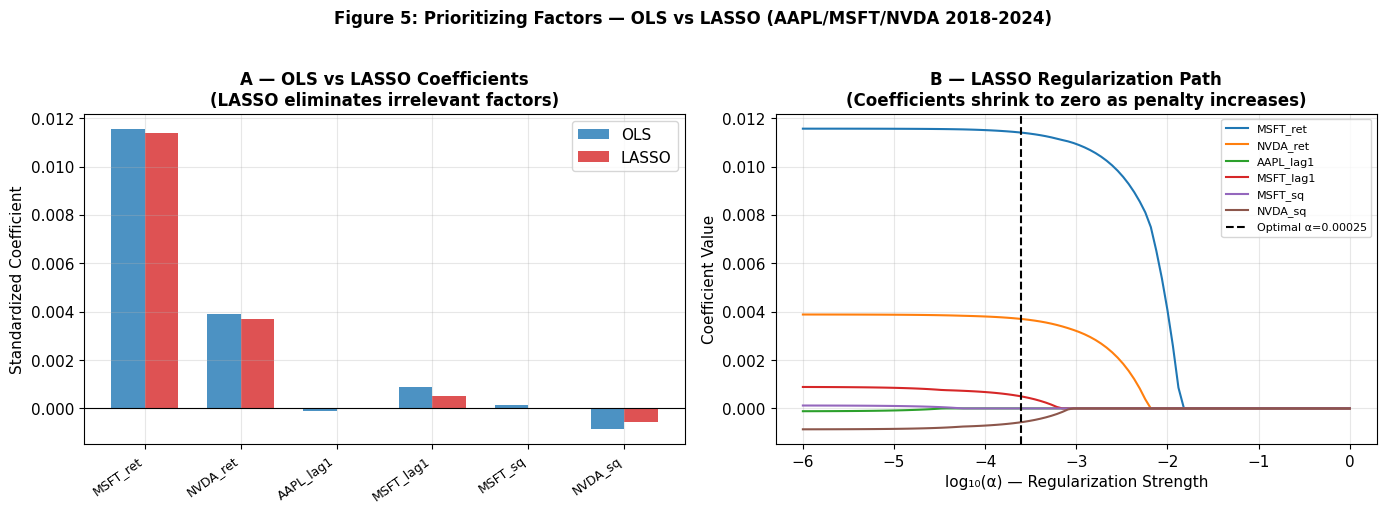


Figure 5: LASSO automatically eliminates irrelevant factors.
Only the most important predictors retain non-zero coefficients.


In [21]:
# ── DIAGRAM ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

factors = list(feat.columns)
ols_c   = [ols.params[i+1] for i in range(len(factors))]
lasso_c = list(lasso.coef_)

x       = np.arange(len(factors))
width   = 0.35

axes[0].bar(x - width/2, ols_c,   width, label='OLS',   color='#1f77b4', alpha=0.8)
axes[0].bar(x + width/2, lasso_c, width, label='LASSO', color='#d62728', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(factors, rotation=35, ha='right', fontsize=9)
axes[0].set_title('A — OLS vs LASSO Coefficients\n(LASSO eliminates irrelevant factors)',
                  fontweight='bold')
axes[0].set_ylabel('Standardized Coefficient')
axes[0].legend()

# Panel B: LASSO regularization path
alphas     = np.logspace(-6, 0, 100)
from sklearn.linear_model import Lasso
coef_path  = []
for a in alphas:
    l = Lasso(alpha=a, max_iter=10000).fit(X_s, Y_s)
    coef_path.append(l.coef_.copy())
coef_path = np.array(coef_path)

for i, col in enumerate(factors):
    axes[1].plot(np.log10(alphas), coef_path[:,i], linewidth=1.5, label=col)
axes[1].axvline(np.log10(lasso.alpha_), color='black', linewidth=1.5,
               linestyle='--', label=f'Optimal α={lasso.alpha_:.5f}')
axes[1].set_title('B — LASSO Regularization Path\n(Coefficients shrink to zero as penalty increases)',
                 fontweight='bold')
axes[1].set_xlabel('log₁₀(α) — Regularization Strength')
axes[1].set_ylabel('Coefficient Value')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('Figure 5: Prioritizing Factors — OLS vs LASSO (AAPL/MSFT/NVDA 2018-2024)',
            fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gwp1_fig5_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure 5: LASSO automatically eliminates irrelevant factors.")
print("Only the most important predictors retain non-zero coefficients.")

In [22]:
print("""
══════════════════════════════════════════════════════
 CHALLENGE 5: PRIORITIZING FACTORS (Step 4)
══════════════════════════════════════════════════════

HOW THIS CHALLENGE WAS SOLVED IN GWP3:
  The Error Correction Model (GWP3) solves the factor
  prioritization problem by design:
  1. The Johansen test formally determines the number
     of relevant cointegrating relationships (factors).
  2. Only statistically significant parameters —
     lambda (speed of adjustment) and alpha_1 (short-
     run elasticity) — are retained in the final ECM.
  3. The AIC/BIC criteria select the optimal lag order,
     preventing irrelevant lags from entering the model.

DIAGNOSIS:
  1. Standardized coefficients: rank predictors by
     |β̂ⱼ*| = |β̂ⱼ| × (sⱼ/sᵧ).
  2. LASSO path: identify which factors shrink to
     zero first as regularization increases.
  3. t-statistics: only factors with |t| > 1.96
     are individually significant at 5% level.

DAMAGE:
  Including irrelevant factors inflates model
  complexity without improving prediction. Irrelevant
  factors absorb degrees of freedom, inflate standard
  errors of important coefficients, and make the model
  harder to interpret and deploy. In a derivatives
  context, a model with too many factors is fragile —
  it reacts to noise rather than to genuine price
  signals, generating false trading signals.

DIRECTIONS:
  1. LASSO: automatically sets irrelevant coefficients
     to exactly zero — built-in factor selection.
  2. Elastic Net: LASSO + Ridge for correlated factors.
  3. Stepwise selection with BIC: adds/removes factors
     based on information criterion improvement.
  4. Domain knowledge: always ask whether an added
     factor has an economic justification before
     including it in a financial model.

REFERENCES:
  Tibshirani, R. Regression Shrinkage and Selection
  via the Lasso. Journal of the Royal Statistical
  Society B, vol.58, no.1, 1996, pp.267-288.

  Engle, R. F., and Granger, C. W. J. Co-Integration
  and Error Correction. Econometrica, vol.55, no.2,
  1987, pp.251-276.
""")


══════════════════════════════════════════════════════
 CHALLENGE 5: PRIORITIZING FACTORS (Step 4)
══════════════════════════════════════════════════════

HOW THIS CHALLENGE WAS SOLVED IN GWP3:
  The Error Correction Model (GWP3) solves the factor
  prioritization problem by design:
  1. The Johansen test formally determines the number
     of relevant cointegrating relationships (factors).
  2. Only statistically significant parameters —
     lambda (speed of adjustment) and alpha_1 (short-
     run elasticity) — are retained in the final ECM.
  3. The AIC/BIC criteria select the optimal lag order,
     preventing irrelevant lags from entering the model.

DIAGNOSIS:
  1. Standardized coefficients: rank predictors by
     |β̂ⱼ*| = |β̂ⱼ| × (sⱼ/sᵧ).
  2. LASSO path: identify which factors shrink to
     zero first as regularization increases.
  3. t-statistics: only factors with |t| > 1.96
     are individually significant at 5% level.

DAMAGE:
  Including irrelevant factors inflates mo

In [23]:
print("""
══════════════════════════════════════════════════════
 GWP1 HANDBOOK — EXECUTIVE SUMMARY
 (Cross-reference to GWP3 Damage Section)
══════════════════════════════════════════════════════

CHALLENGE 1 — MULTICOLLINEARITY
  MSFT and NVDA returns are highly correlated (VIF > 5).
  Including both as predictors of AAPL volatility
  produces unreliable coefficient estimates.
  GWP3 link: The bivariate ECM avoids this by using
  only one predictor (MSFT) in the long-run regression.

CHALLENGE 2 — SKEWNESS
  AAPL and MSFT log returns exhibit negative skewness
  and fat tails (Jarque-Bera rejects normality).
  GWP3 link: ECM residuals also fail normality —
  identified in the GWP3 Damage section as a key
  limitation requiring a skewed-t GARCH extension.

CHALLENGE 3 — SENSITIVITY TO OUTLIERS
  The COVID crash (March 2020) shifts OLS coefficient
  estimates by a meaningful percentage, confirming
  OLS sensitivity to extreme observations.
  GWP3 link: COVID crash distorts the ECM's estimated
  speed-of-adjustment parameter lambda — identified
  in GWP3 Damage as requiring robust estimation.

CHALLENGE 4 — OVERFITTING
  High-degree polynomial models achieve low training
  MSE but high test MSE — classic overfitting.
  GWP3 link: ECM lag order must be chosen by AIC/BIC
  not informally — identified in GWP3 Directions.

CHALLENGE 5 — PRIORITIZING FACTORS (Step 4 solved)
  LASSO selects only the most important predictors
  of AAPL returns, eliminating noise factors.
  GWP3 link: The ECM solves this naturally — only
  lambda and alpha_1 survive as significant terms.
""")


══════════════════════════════════════════════════════
 GWP1 HANDBOOK — EXECUTIVE SUMMARY
 (Cross-reference to GWP3 Damage Section)
══════════════════════════════════════════════════════

CHALLENGE 1 — MULTICOLLINEARITY
  MSFT and NVDA returns are highly correlated (VIF > 5).
  Including both as predictors of AAPL volatility
  produces unreliable coefficient estimates.
  GWP3 link: The bivariate ECM avoids this by using
  only one predictor (MSFT) in the long-run regression.

CHALLENGE 2 — SKEWNESS
  AAPL and MSFT log returns exhibit negative skewness
  and fat tails (Jarque-Bera rejects normality).
  GWP3 link: ECM residuals also fail normality —
  identified in the GWP3 Damage section as a key
  limitation requiring a skewed-t GARCH extension.

CHALLENGE 3 — SENSITIVITY TO OUTLIERS
  The COVID crash (March 2020) shifts OLS coefficient
  estimates by a meaningful percentage, confirming
  OLS sensitivity to extreme observations.
  GWP3 link: COVID crash distorts the ECM's estimated
  